# Stochastic Processes and Simulation   
## Monte-Carlo Integration
### Gohar Aleksanyan
**17.06.2026**

## 1. Monte-Carlo Integration and Importance Sampling

Let $X$ be a random variable with distribution function $F$ and density function $f_X$.
The goal is to numerically approximate the expectation
$$\theta = \mathbb{E}[h(X)] =\int h(x) f_X(x)dx.$$
The Monte Carlo algorithm computes $n$ independent samples from the distribution $F$, and the respective values $h(X_i)$.
By the law of large numbers the computed average 
$$\overline{h(X)}_n =\frac 1 n \sum h(X_i) \rightarrow \mathbb{E}[h(X)]~ a.s. . $$
Furthermore, using the central limit theorem, we can approximate the convergence error, 
$$
\frac{\overline{h(X)}_n- \theta}{\sqrt n \sigma}  \thickapprox   \mathrm{N}(0,1).
$$
Importance sampling generalizes Monte Carlo to improve the convergence rate by reducing the variance of the estimators. We consider a random variable $Y$ with a distribution $G$, such that whenever $f_X(x)> 0$ then $f_Y(x) > 0$, and the weight function $w(x):=\frac{f_X(x)}{f_Y(x)}$ is well defined.
Then 
$$
\mathbb{E}[h(X)] =\mathbb{E}[h(Y)w(Y)].
$$
The algorithm now takes $n$ independent samples $Y_1,Y_2,..., Y_n$ from the distribution of $Y$, and computes $ h(Y_i)$, as well as
$ w(Y_i)$. Then the integral and the error are approximated like in the crude Monte Carlo method. 


First we compare the performance of the crude Monte Carlo method and Monte Carlo with importance sampling by calculating 
$$\mathbb{P}(X >10)= \mathbb{E}[\textbf{1}_{\{X >10 \}} ] \quad \textrm{for}\quad X \sim \mathrm{Exp(1)}.$$

Assuming that the number of draws $n= 10^5$, we calculate the expected number of times that $ \textbf{1}_{ \{X_i >10 \} }=1$, for $1\leq i \leq n$.
Let $X_1,...,X_n$ be a sequence of identiaclly distributed
independent random variables, corresponding to the $n$ number of draws. Consider respective counting random variables; $C_i = \textbf{1}_{X_i}$, 
then $C_i=1$ with probability $\mathbb{P}(X_i >10):= p=e^{-10}$, and $0$, otherwise.
Then the expected number of times 
$ \textbf{1}_{ \{ X_i >10 \} }=1$ is 
$$ \mathbb{ E}[\sum_{i=1}^{n} C_i]=\sum_{i=1}^{n} \mathbb{E}[C_i]= n p= n e^{-10}\approx 4.54.$$

In [118]:
import numpy as np
n = 10**5
expected_count = n * np.exp(-10)
print(expected_count)

4.539992976248485


Next we derive a $95$% confidence interval for the number of draws. Let $X_1,...,X_n$ be a sequence of identiaclly distributed
independent random variables, corresponding to the $n$ number of draws. Consider respective counting random variables; $C_i = \textbf{1}_{X_i}$, 
then $C_i=1$ with probability $p=e^{-10}$, and $0$, otherwise. Hence  $\mu:=\mathbb{E}[C_i]=p$ and $\sigma^2:= \mathrm{Var}( C_i) =
p-p^2$.
By Central Limit Theorem for the identically distributed independent random variables $C_i$; $ \frac{\sum_1^n C_i -np}{ \sqrt{n p(1-p)} }$ is approximately normal distributed, where $\sum_1^n C_i$ is the total number of counts. Hence we obtain the $95$ %-confidence interval for $\sum_1^n C_i$ by the formula 
$$ np \pm  \sqrt{np(1-p)} \Phi^{-1}(0.975),$$
where $\Phi$ is the cumulative distribution function for the normal distribution. By substituting the numerical values in the formula above, we get the $95$% confidence interval 
$(0.364, 8.716)$.

In [119]:
n = 10**5
p = np.exp(-10)
# Mean and standard deviation of the count
mu_count = n * p
sigma_count = np.sqrt(n * p * (1 - p))

# 95% confidence interval
lower = mu_count - 1.96 * sigma_count
upper = mu_count + 1.96 * sigma_count
print(f"95% Confidence interval: ({lower:.3f}, {upper:.3f})")

95% Confidence interval: (0.364, 8.716)


For importance sampling we consider exponentially distributed random vaiable $Y$, such that $Y \sim \mathrm{Exp}(\tfrac{1}{10})$. First we compute the 
weight function $w =\frac{f_X(x)}{f_Y(x)}$. We have that $X\sim \mathrm{Exp}(1)$, and $Y\sim \mathrm{Exp}(\tfrac{1}{10})$, hence
$$ w(x)=\frac{f_X(x)}{f_Y(x)}= \frac{  e^{-x}}{ 10^{-1}e^{-\frac{1}{10}x}}=10 e^{-\frac{9}{10}x}, \quad \textrm{for}\quad x \geq 0.$$

In this task we implement crude Monte Carlo and Monte Carlo with importance sampling, taking $Y \sim \mathrm{Exp}(\tfrac{1}{10})$. 
We compute the relative error $|\tfrac{\hat p}{p}-1|$ for both methods, where $p=\mathbb{P}(X > 10) = e^{-10}$, and
$ \hat p$ is the empirical esitamate of $p$.


In [121]:
import matplotlib.pyplot as plt

p_true = np.exp(-10) #theoretical probability p

#empirical probability for crude Monte Carlo
def crude_mc(n):
    X = np.random.exponential(scale=1, size=n)
    p_hat = np.mean(X > 10)
    return p_hat

# empirical probability Monte carlo with importance sampling
def importance_sampling(n):
    Y = np.random.exponential(scale=10, size=n)
    w = 10 * np.exp(-0.9 * Y)
    p_hat = np.mean((Y > 10) * w)
    return p_hat

N = [10, 100, 1000, 10000, 100000, 1000000] #drarws
relative_err_cmc = []
relative_err_mcis = []

for n in N:
    p_cmc = crude_mc(n)
    p_mcis = importance_sampling(n)
    relative_err_cmc.append(abs(p_cmc / p_true - 1))
    relative_err_mcis.append(abs(p_mcis / p_true - 1))

Now let us compare the obained numbers;

In [122]:
import pandas as pd
df = pd.DataFrame({
    "Draws (n)": N,
    "Relative Error crude MC": relative_err_cmc,
    "Relative Error MC IS": relative_err_mcis
})

df = df.round(3)
print(df)

   Draws (n)  Relative Error crude MC  Relative Error MC IS
0         10                    1.000                 0.984
1        100                    1.000                 0.181
2       1000                    1.000                 0.129
3      10000                    1.000                 0.014
4     100000                    0.119                 0.019
5    1000000                    0.097                 0.006


We see that the relative errors are much smaller for the Monte Carlo method with importance sampling, especially when the number of draws is large.  We draw the same conclusion by looking at the respective plots.

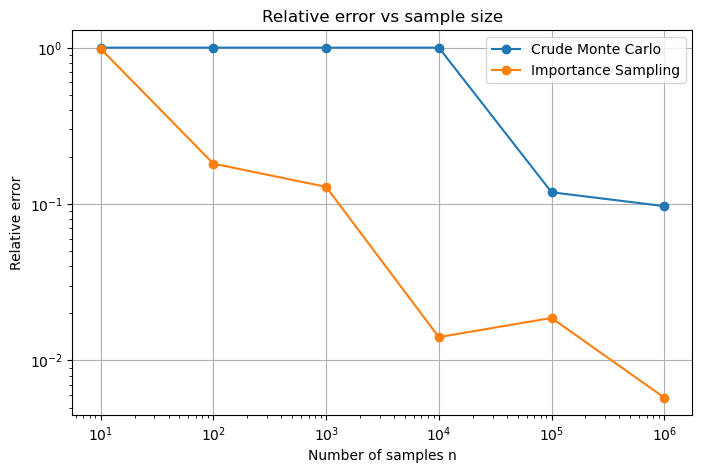

In [123]:
plt.figure(figsize=(8,5))
plt.plot(N, relative_err_cmc, marker='o', label='Crude Monte Carlo')
plt.plot(N, relative_err_mcis, marker='o', label='Importance Sampling')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of samples n')
plt.ylabel('Relative error')
plt.title('Relative error vs sample size')
plt.legend()
plt.grid(True)
plt.show()

 Next we build the $95$% confidence intervals for probabilities for different values of draws $n, ~n \in \{ 10, 10^2,..., 10^6\}:= N$;
$$\hat p \pm 1.96 \sqrt{\frac{\mathrm{Var}(\hat p)}{n}}= \hat p \pm \frac{1.96}{\sqrt n} \mathrm{sd}(\hat p),$$ 
and plot the results.

In [124]:
p_hat_list = []
sd_hat_list = []
lower_list = []
upper_list = []

for n in N:
    X = np.random.exponential(scale=1, size=n)
    Z = (X > 10).astype(float)
    p_hat = np.mean(Z)
    sd_hat = np.std(Z, ddof=1)
    lower = p_hat - 1.96 * sd_hat / np.sqrt(n)
    upper = p_hat + 1.96 * sd_hat / np.sqrt(n)
    p_hat_list.append(p_hat)
    sd_hat_list.append(sd_hat)
    lower_list.append(lower)
    upper_list.append(upper)


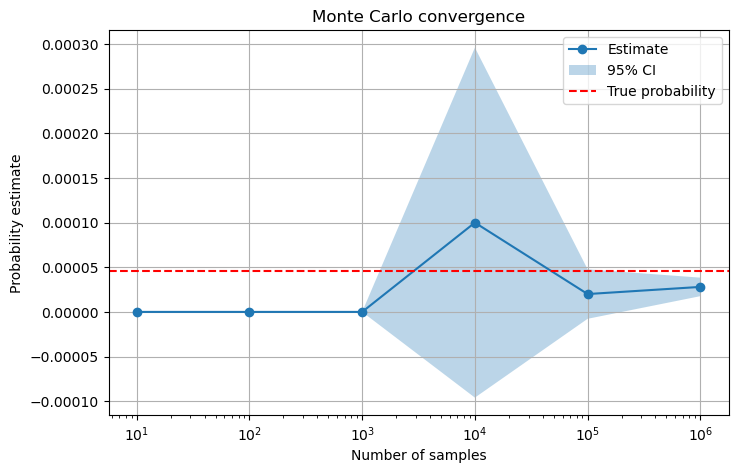

In [125]:
plt.figure(figsize=(8,5))
plt.plot(N, p_hat_list, marker='o', label='Estimate')

plt.fill_between(
    N,
    lower_list,
    upper_list,
    alpha=0.3,
    label='95% CI'
)

plt.axhline(
    p_true,
    linestyle='--',
    color='red',
    label='True probability'
)

plt.xscale('log')
plt.xlabel('Number of samples')
plt.ylabel('Probability estimate')
plt.title('Monte Carlo convergence')
plt.legend()
plt.grid(True)
plt.show()


We observe that for large number of draws $n= 10^5, ~n=10^6$, the estimeted value of $p~$, $ \hat p$, approaches the theoretical value $p$,
and that the length of confidence interval is decreasing.

Now let us consider an importance sampling method with the random variable $Y= X+10$. The goal is to 
explore why its called an "optimal" importance sampling by inplementing a similar analysis as in the previous task.  

We start by calculating the distribution function for $Y$, clearly  $ F_Y(y)=\mathbb{P}(Y \geq y)= F_X(y-10)$, and after differentiating we get
$ f_Y(y)= f_X (y-10)= e^{-(y-10)}$, for $y\geq 10$, and $0$ otherwise. Next we calculate the weight function 
$$w(y)=\frac{f_X(y)}{f_Y(y)}=\frac{e^{-y}}{e^{-(y-10)}}=e^{-10}=p$$
 is constant for $ y \geq 10$ .
Having a const weight is a great advantage, as it implies that
$$ 
\hat p = \frac 1 n \sum_{i=1}^n \textbf{1}_{\{Y_i > 10 \}} w(Y_i)= \frac 1 n \sum_{i=1}^n p= p,
$$
hence the observed values for the probability are the same as the theoretical value. 

In this example, the minimum variance $ 0$ is attained, which is not always possible to achieve.


In [126]:
def optimal_importance_sampling(n):

    Y = np.random.exponential(scale=1, size=n) + 10
    w = np.exp(-10)
    p_hat = np.mean(w * np.ones(n))
    return p_hat

# the epmirical values of the probability are very close to teh theoretical
## we check it by looking at the  values which are almost 1
for n in N:
    print(np.exp(10)*optimal_importance_sampling(n))

1.0
1.0
1.0000000000000002
1.0
1.0
1.0000000000000002


## 2. Default of an insurance company  

Consider an insurance company that starts with Capital $ C$ at time $t=0$. Each year it gains a fixed value $r > 0$ in 
premiums and looses $X \sim F$ independently of other years. Hence the capital at the end of year $t $ is
$$Z_t= C +tr - \sum_{i=1}^t X_i.$$
The company is in default if $ Z_t \leq 0$.  


The probability of default for the company in the next $T$ years is calculated:
$$\mathbb{P} (\min_{0 <t\leq T} Z_t < 0)= \mathbb{E}[\textbf{1}_{ \{\min_{t} Z_t < 0\}}] .$$
Assuming that $C=10$, $ r=1 $ and losses are independent and log-normally distributed, $X \sim \mathrm{LogNorm}(0,\tfrac 1 4)$, we 
approximate the probability of default for the company in the next  $ T =20$ years.

In [138]:
C = 10
r = 1
T = 20

def default_probability_mc(n):
    defaults = np.zeros(n)
    for j in range(n):
        X = np.random.lognormal(mean=0, sigma=0.5, size=T)
        Z = C + r * np.arange(1, T+1) - np.cumsum(X)
        defaults[j] = np.min(Z) < 0

    p_hat = np.mean(defaults)
    sd_hat = np.std(defaults, ddof=1)
    lower = p_hat - 1.96 * sd_hat / np.sqrt(n)
    upper = p_hat + 1.96 * sd_hat / np.sqrt(n)
    return p_hat, lower, upper

n=100000
default_probability_mc(n)

(np.float64(0.00957),
 np.float64(0.008966571101333424),
 np.float64(0.010173428898666577))

Taking the number of draws $n=10^5$, we obtained an estimated value for the probability of default $ \approx 0.0096$, and a $95$% confidence
interval $ \approx (0,009, 0.0102)$.

Next we plot the probability convergence with a $95$% confidence interval with respect to number of samples $n, ~ n \in N:=\{10, 10^2, ..., 10^6\}$.

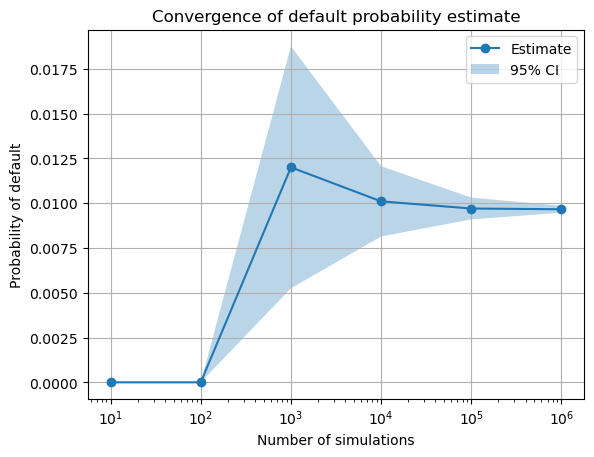

In [139]:
N = [10, 100, 1000, 10000, 100000, 1000000]
estimates = []
lower_ci = []
upper_ci = []

for n in N:
    p_hat, lower, upper = default_probability_mc(n)
    estimates.append(p_hat)
    lower_ci.append(lower)
    upper_ci.append(upper)

plt.plot(N, estimates, marker='o', label='Estimate')
plt.fill_between(
    N,
    lower_ci,
    upper_ci,
    alpha=0.3,
    label='95% CI'
)

plt.xscale('log')
plt.xlabel('Number of simulations')
plt.ylabel('Probability of default')
plt.title('Convergence of default probability estimate')
plt.legend()
plt.grid(True)
plt.show()

Based on the simulation above, and looking at the plot, we observe that for large number of draws the probability of default is approaching $0.01$, which corresponds to $1$%. 


Now let us approximate the probability of default for the company in the next $T=20$ years using importance sampling.

We consider a random variable $Y \sim \mathrm{LogNorm}(\mu,\tfrac 1 4)$, where the parameter $\mu $ to be chosen. First let us calculate the density fuctions and the weight function. We have that $\ln X \sim \mathrm{N}(0, \sigma^2)$, where $X >  0$ and $\sigma^2=\tfrac 1 4$, hence 
$$ F_X(x)= \mathbb{P} (X \leq  x)= 
\mathbb{P} (\ln X \leq  \ln x)=\frac{1}{\sqrt{2 \pi \sigma^2}}\int^{\ln x}_{- \infty} e^{- \frac{t^2}{2 \sigma^2}} dt$$
and after differentiating, we obtain the density function $ f_X (x )= \frac{1}{x \sqrt{2 \pi \sigma^2}} e^{-\frac{(\ln x)^2}{2 \sigma^2}}$. Similarly, we compute $f_Y (x )= \frac{1}{x \sqrt{2 \pi \sigma^2}} e^{-\frac{(\ln x-\mu)^2}{2 \sigma^2}} $, and the weight function 
$$ w(x)=\frac{f_X(x)}{f_Y(x)}=e^{\frac{(\ln x-\mu)^2 - (\ln x)^2}{ 2 \sigma^2}}= e^{-\frac{2 \mu \ln x-\mu^2}{ 2 \sigma^2}}
= \frac{e^{2 \mu^2}}{x^{4 \mu}}, $$
since $\sigma= \tfrac 1 2$.

In [129]:
sigma = 0.5
sigma2 = sigma**2
N = [10, 100, 1000, 10000, 100000]

def importance_sampling(n, mu):
    Z_vals = np.zeros(n)
    for i in range(n):
        Y = np.random.lognormal(mean=mu, sigma=sigma, size=T)
        capital = C + np.arange(1, T+1) - np.cumsum(Y)
        indicator = (np.min(capital) < 0)
        logY = np.log(Y)
        w = np.exp(2 * mu**2) * Y**(-4 * mu)
        weight = np.prod(w)
        Z_vals[i] = indicator * weight

    p_hat = np.mean(Z_vals)
    sd = np.std(Z_vals, ddof=1)

    lower = p_hat - 1.96 * sd / np.sqrt(n)
    upper = p_hat + 1.96 * sd / np.sqrt(n)
    return p_hat, sd, lower, upper


In the last step we plot the confidence interval for various values of $\mu, ~\mu \in \{0, 0.2, 0.4,  0.6, 0.8, 1.0\}$, and choose the one with the minimum variance, $\mathrm{Var}(h(Y)w(y))$. Let us observe that $\mu =0 $ corresponds to the crude Monte Carlo method, and we are hoping to find a $\mu > 0$ which allows sampling of more extreme losses, and which gives a smaller variance.

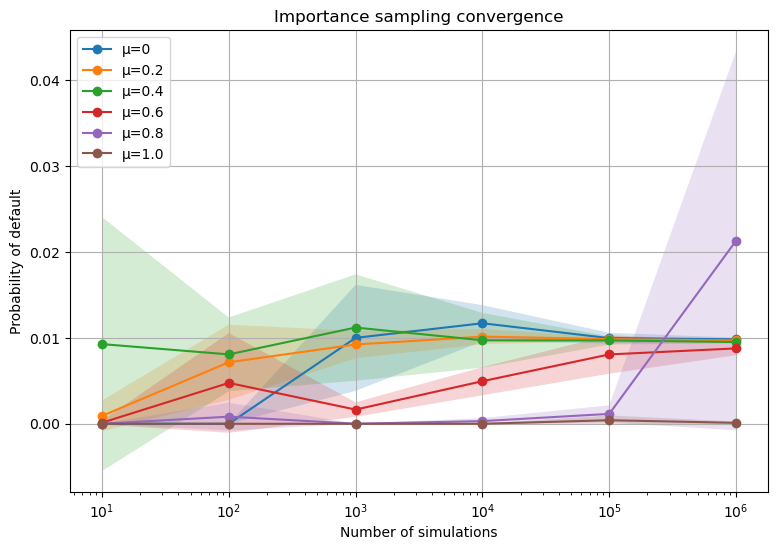

In [140]:
mus = [0, 0.2,0.4,0.6,0.8,1.0]
results = {}
variance_summary = {}

for mu in mus:
    estimates = []
    lower_ci = []
    upper_ci = []
    sd_values = []
    var_values = []

    for n in N:
        p_hat, sd, lower, upper = importance_sampling(n, mu)
        estimates.append(p_hat)
        lower_ci.append(lower)
        upper_ci.append(upper)
        sd_values.append(sd)
        var_values.append(sd**2)

    results[mu] = (estimates, sd_values, var_values, lower_ci, upper_ci)
    # store average variance across all n for model comparison
    variance_summary[mu] = np.mean(var_values)

plt.figure(figsize=(9,6))

for mu in mus:
    estimates, sd_values, var_values, lower_ci, upper_ci = results[mu]
    plt.plot(N, estimates, marker='o', label=f'μ={mu}')
    plt.fill_between(N, lower_ci, upper_ci, alpha=0.2)

plt.xscale('log')
plt.xlabel("Number of simulations")
plt.ylabel("Probability of default")
plt.title("Importance sampling convergence")
plt.legend()
plt.grid(True)
plt.show()

The simulation above and plotting the confidence intervals does not provide sufficient evidence for choosing $\mu$.
In the next step we find the $\mu$ corresponding to the least variance in the simulation above as the optimal value.


In [142]:
variance_table = pd.DataFrame({
    "mu": list(variance_summary.keys()),
    "avg_variance": [round(v, 6) for v in variance_summary.values()]
})

print("\nVariance summary:")
print(variance_table)
best_mu = min(variance_summary, key=variance_summary.get)
min_var = variance_summary[best_mu]
print("\nBest μ based on minimum average variance:")
print(f"μ = {best_mu}, variance = {round(min_var, 6)}")


Variance summary:
    mu  avg_variance
0  0.0      0.006847
1  0.2      0.000945
2  0.4      0.008177
3  0.6      0.050873
4  0.8     21.141284
5  1.0      0.002366

Best μ based on minimum average variance:
μ = 0.2, variance = 0.000945


## 3. Markov Chain Monte Carlo

Markov chain Monte Carlo algorithm is used when simulating from a given distribution is difficult, so the method constructs a Markov chain $X_1,..., X_n$ that converges to a target ditrsibution $P$.

As before, the goal is to approximate $\mathbb{E}[h(X)]$ based on random draws $X_1, ..., X_n$, where $ X_i $ form a Marcov chain.


### Gibbs sampling  
Gibbs sampling is a Markov Chain Monte Carlo algoorithm that is used to generate samples from a multivariate  probability distribution, using sampling from the conditional distributions.

Let $ \textbf{X}:=(X_1,X_2)$ follow a bivariate Normal distribution with mean $\mu=(0,0)$ and covariance matrix 
$$\Sigma =
\begin{pmatrix}
1 & \rho \\
\rho & 1
\end{pmatrix}.$$ 

The algorithm starts with an initial value $\textbf{X}^{(0)}$, and obtains the following samples iteratively; 
$$
X_1 ^{k+1} \sim P(X_1 | X_2^{(k)}), \quad X_2 ^{k+1} \sim P(X_2 | X_1^{(k+1)}).
$$

  
First let us derive the conditional distributions $X_1 |X_2 $ and $X_2 |X_1 $. Let $f(x,y)$ denote the joint distribution
for the random variable
$(X_1,X_2)$,
then 
$$f(X_1| X_2) (x_1|x_2)= \frac{f(x_1, x_2)}{f_{X_2}(x_2)}= \frac{\sqrt{2 \pi}}{2 \pi \sqrt{1-\rho^2}} 
\frac{ e^{-\frac{x_1^2-2\rho x_1 x_2 +x_2^2 }{2(1-\rho^2)}}}{e^{-\frac{x_2^2}{2}}} = \frac{1}{\sqrt{2 \pi (1 -\rho^2)}} e^{-\frac{(x_1-\rho x_2)^2}{2(1-\rho^2)}},$$
similarly, by symmetry,  $f(X_2| X_1)=  \frac{1}{\sqrt{2 \pi (1 -\rho^2)}} e^{-\frac{(x_2-\rho x_1)^2}{2(1-\rho^2)}}$. Hence
$$ X_1| X_2 \sim \mathrm{N}(\rho x_2, 1-\rho^2 ) \quad \textrm{and} \quad  X_2| X_1 \sim \mathrm{N}(\rho x_1, 1-\rho^2 ).$$




Now let us implement Gibbs sampling, based on our calculations for conditional distributions above and with $ \rho=0.8$

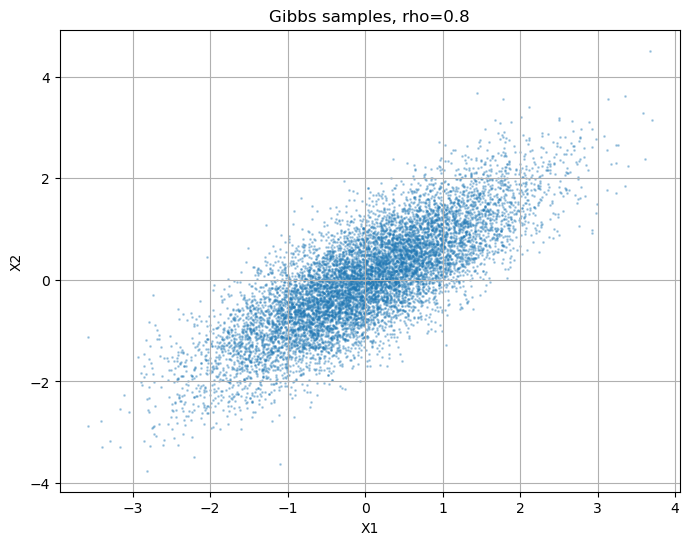

In [143]:
rho = 0.8
sigma = np.sqrt(1 - rho**2)
n_samples = 10000
samples = np.zeros((n_samples, 2))

# Initial state
x1 = 0
x2 = 0
for t in range(n_samples):
    x1 = np.random.normal(loc=rho * x2, scale=sigma)
    x2 = np.random.normal(loc=rho * x1, scale=sigma)
    samples[t] = [x1, x2]

plt.figure(figsize=(8,6))
plt.scatter(samples[:,0], samples[:,1], s=1, alpha=0.3)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Gibbs samples, rho=0.8")
plt.grid(True)
plt.show()



Next we compute empirical variance of $X_1$, when $ \rho =0.8$. Then we plot the variance with respect to different values of $\rho$.


1.0226753778838278
[1.038 1.002 1.004 1.016 0.99  1.003 1.012 0.98  1.096]


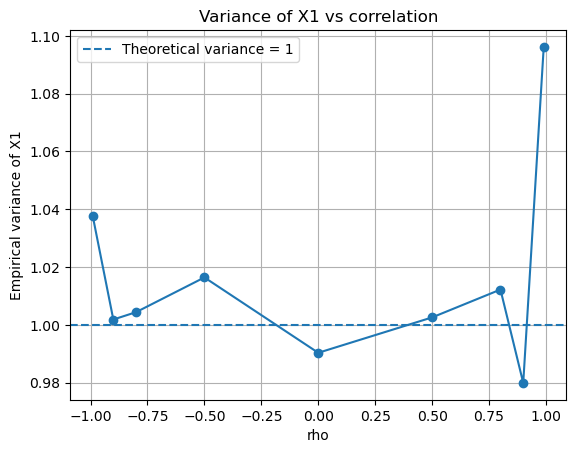

In [144]:
var_x1 = np.var(samples[:,0], ddof=1)
print(var_x1)

def gibbs_sampler(rho, n_samples=10000):
    sigma = np.sqrt(1 - rho**2)
    samples = np.zeros((n_samples, 2))
    x1, x2 = 0, 0

    for t in range(n_samples):
        x1 = np.random.normal(rho * x2, sigma)
        x2 = np.random.normal(rho * x1, sigma)
        samples[t] = [x1, x2]
    return samples

rhos = [-0.99, -0.9, -0.8, -0.5, 0, 0.5, 0.8, 0.9, 0.99]
variances = []

for rho in rhos:
    samples = gibbs_sampler(rho)
    variances.append(np.var(samples[:,0], ddof=1))

print(np.round(variances, 3))

plt.plot(rhos, variances, marker='o')
plt.axhline(1, linestyle='--', label='Theoretical variance = 1')
plt.xlabel('rho')
plt.ylabel('Empirical variance of X1')
plt.title('Variance of X1 vs correlation')
plt.legend()
plt.grid(True)
plt.show()

We get that the empirical variance of $ \mathrm{Var(X_1)}\approx 1.023 $, which is reasonable since the actual variance is $1$.
The variance does not depend on $\rho$, however the plot above indicates that when the absolute value of $\rho$ is close to $1$ the empirical estimate of the variance is less accurate.  This is due to the fact when  $| \rho| \approx 1  $, then the successive samples are highly correlated, negatively impacting the efficiency of the algorithm.

### The 2D Ising model  
The square lattice Ising model describes interacting magnetic spins, it consists of a grid (lattice) of cells, 
representing atomic spins. Each spin can point either up (+1) or down (-1), and interacts with its nearest adjacent spins: left, right, 
above and below.

We consider the lattice $ J_k= \{1,...,k\} \times \{ 1,..., k \}$, for each $i \in J_k$, the variable $\sigma_i \in \{-1,1\}$
represents the site's spin, and the corresponding matrix $ \sigma := \{(\sigma)_i\}_{i \in J_k}$ is called a spin configuration. 
The energy of the configuration is defined as 
$$H(\sigma):=- \beta \sum_{i\sim j}\sigma_i \sigma_j,$$
where the sum is taken over pairs of adjacent cites. The probability of configuration $\sigma$ is given by 
$ \pi_\sigma = C_\beta e^{H(\sigma)}$, where $C_\beta $ is a normalization constant. The conditional distribution of $i$-th
coordinate of $\sigma$,  given other coordinates, is 
$$ p(\sigma_i =1| \{\sigma_j; j \neq i\})= \left(1 + e^{2 \beta \sum_{j: j \sim i} \sigma_j} \right)^{-1}.$$



We use Gibbs sampling to simulate the Ising model with $\beta = 5$, $ k= 10$, and randomly chosen initial configuration.

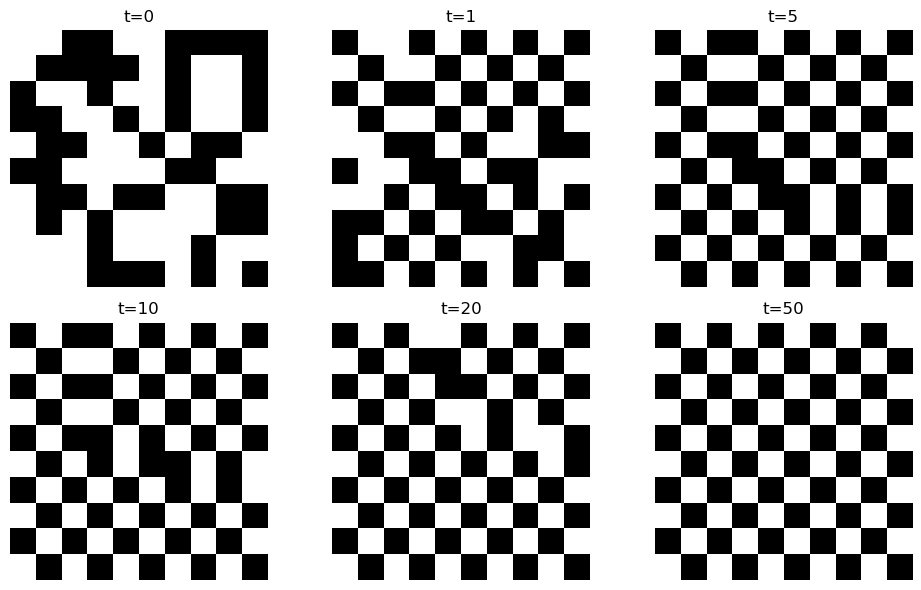

In [71]:
k = 10 
beta = 5
sigma = np.random.choice([-1, 1], size=(k, k))
def neighbor_sum(spins, i, j):
    s = 0
    k = spins.shape[0]
    if i > 0:
        s += spins[i-1, j]
    if i < k-1:
        s += spins[i+1, j]
    if j > 0:
        s += spins[i, j-1]
    if j < k-1:
        s += spins[i, j+1]
    return s

def gibbs_step(spins, beta):
    k = spins.shape[0]
    for i in range(k):
        for j in range(k):
            S = neighbor_sum(spins, i, j)
            p_plus = 1 / (1 + np.exp(2 * beta * S))
            spins[i, j] = 1 if np.random.rand() < p_plus else -1
    return spins
snapshots = []
times = [0, 1, 5, 10, 20, 50]

spins = np.random.choice([-1, 1], size=(k, k))
for t in range(max(times)+1):    
    if t in times:
        snapshots.append(spins.copy())
    spins = gibbs_step(spins, beta)

fig, axes = plt.subplots(2, 3, figsize=(10,6))

for ax, snap, t in zip(axes.flat, snapshots, times):
    ax.imshow(snap, cmap='grey')  ## -1 black, +1 white 
    ax.set_title(f"t={t}")
    ax.axis('off')

plt.tight_layout()
plt.show()

Assuming that $\beta > 0$, we can see theoretically that
if $ \sum_{j: j \sim i} \sigma_j =0$, i.e. $\pm 1$ spins appear eqaully frequently,then  the conditional porbability 
$ p(\sigma_i =1| \{\sigma_j; j \neq i\} =\tfrac 1 2$.  If $  \sum_{j: j \sim i} \sigma_j > 0$ is large then the probability of the next one being $+1$ is small, while if $  \sum_{j: j \sim i} \sigma_j < 0$, i. e. there are more $-1$ values in the neighbourhood, then the probability is close to $1$.

Hence, when $ \beta =5$,  each spin tends to take the opposite value of its neighbors. This leads to an alternating pattern, and after sufficiently many Gibbs updates (around $ t=50$ time steps in our simulation), the lattice approaches a checkerboard configuration, where $+1$ corresponds to black and $-1$ to white.

 
Next let us simulate the model for three different values of $\beta, ~\beta \in \{ -0.7, 0.5 , 5\}$, and compare the results.

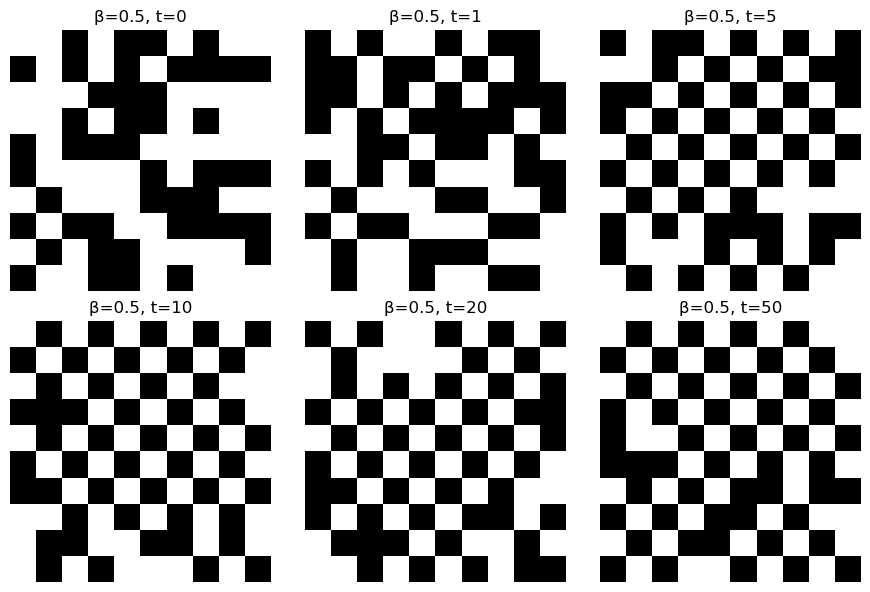

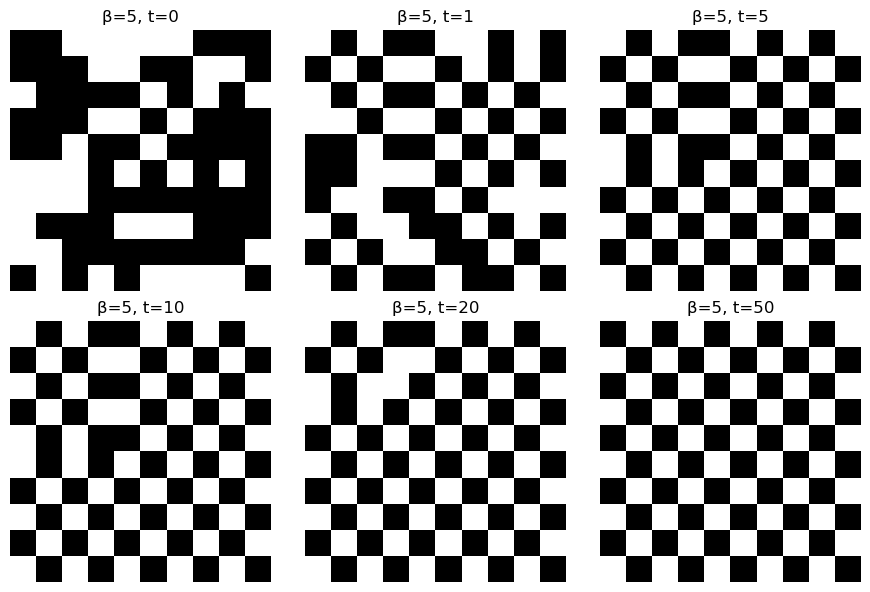

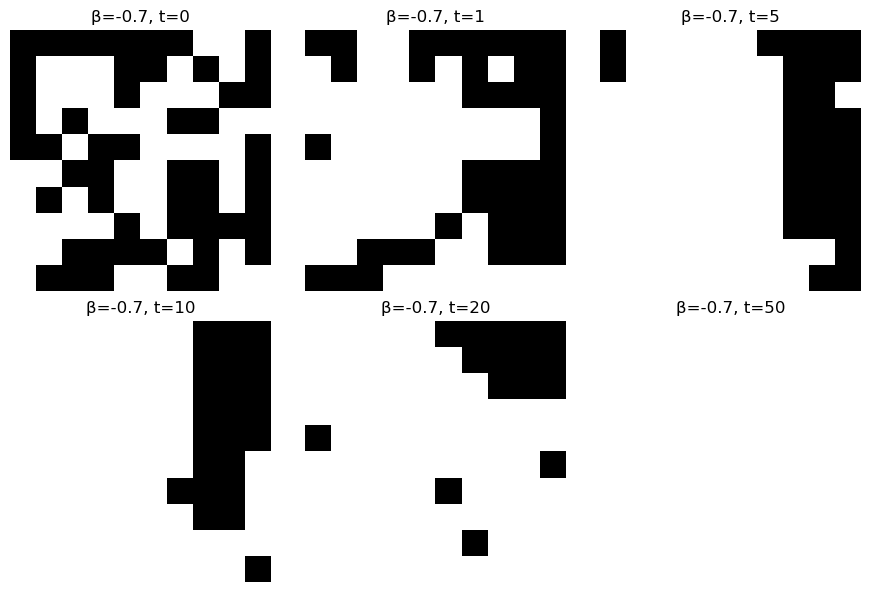

In [87]:
betas = [0.5, 5, -0.7]
def gibbs_step(spins, beta):
    k = spins.shape[0]

    for i in range(k):
        for j in range(k):
            S = neighbor_sum(spins, i, j)
            p_plus = 1 / (1 + np.exp(2 * beta * S))
            if np.random.rand() < p_plus:
                spins[i, j] = 1
            else:
                spins[i, j] = -1
    return spins

def simulate_ising(beta, k=10, steps=50, snapshot_times=[0,1,5,10,20,50]):
    spins = np.random.choice([-1, 1], size=(k, k))
    snapshots = []
    for t in range(steps + 1):
        if t in snapshot_times:
            snapshots.append(spins.copy())
        spins = gibbs_step(spins, beta)
    return snapshots

def plot_snapshots(snapshots, beta, times=[0,1,5,10,20,50]):
    fig, axes = plt.subplots(2, 3, figsize=(9,6))
    for ax, snap, t in zip(axes.flat, snapshots, times):
        ax.imshow(snap, cmap='gray', vmin=-1, vmax=1)
        ax.set_title(f"β={beta}, t={t}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

for beta in betas:
    snapshots = simulate_ising(beta)
    plot_snapshots(snapshots, beta)

The simulation with different values of $ \beta$ is consistent with our  observations earlier, i.e.e when $ \beta =0.5$ the pattern evolves according to the same logic as when $ \beta =5$ but much slower. While when $ \beta =-0.7$ is negative, the pattern changes. As every spin " prefers " neighbours of the same kind,  we observe that after many time steps homogenization occurs, we are left only one kind of spins, which in our simulation corresponds to -1/white at time step $t=50$. 


Now let us simulate a long chain with $n= 10^5$,  $\beta =5$, and $ k= 10$, and calculate the proportion of values of $ \sigma_{2,2}=1$.

In [145]:
beta = 5
k = 10
n_steps = 10000
spins = np.random.choice([-1, 1], size=(k, k))
values = []
for _ in range(n_steps):
    spins = gibbs_step(spins, beta)
    values.append(spins[1,1])  
    # corresponding to sigma (2,2) 

values = np.array(values)
proportion_largebeta = np.mean(values == 1)
print(proportion_largebeta)

1.0


We obtain the value of the proportions equal to $1$, which is consistent with our earlier observation that after large number of steps a checkerboard pattern appears, and the proportion of values for a given cell have a fixed value after long runs. Now let us decrease the number of steps, to see how the proportion changes;

In [146]:
beta = 5
k = 10
n_steps = 100
spins = np.random.choice([-1, 1], size=(k, k))
values = []

for _ in range(n_steps):
    spins = gibbs_step(spins, beta)
    values.append(spins[1,1])

proportion_smallbeta = np.mean(np.array(values) == 1)
print(proportion_smallbeta)

0.95


After decreasing the number of steps to $n=100$, and running a new simulation we observe a proportion $0.95$, which indicates that a steady state has not been reached.

## 4. A single server queue  

The project considers simulation of a single-server queuing system with the set of arrivals times $a_1,a_2,...,a_N$,  and a set of service times
$ s_1,s_2,...,s_N$. We assume that $a_i$ are independent identically distributed random variables, $a_i \sim \mathrm{Exp}(\lambda)$,  and 
that $s_i$ are independent identically distributed random variables, $s_i \sim \mathrm{Exp}(\mu)$, where $\mu > 0,~ \lambda > 0$.

The goal is to compute the number of customers, $ N(t)$ at time $t$, which can be done recursively by first calculating the exit times, $e_1, ...,e_N$;
$$ e_1 =a_1+s_1, \quad e_2= \max(a_2,e_1)+s_2,\quad ..., \quad e_N=\max(a_N, e_{N-1})+s_N.$$


First we write a function, compute_exit_times(arrival, service),  that returns a vector of exit-times (exit_times in our code) given arrival and service times.

In [79]:
def compute_exit_times(arrival, service):
    N = len(arrival)
    exit_times = np.zeros(N)
    exit_times[0] = arrival[0] + service[0]

    for i in range(1, N):
        start_service = max(arrival[i], exit_times[i-1])
        exit_times[i] = start_service + service[i]
    return exit_times

Then we write a function queue_length(arrival, service, t_grid),  that computes the number of people, $N(t)$ in the queue given arrival and service times.

In [99]:
def queue_length(arrival, service, t_grid):
    exit_times = compute_exit_times(arrival, service)
    N_t = np.zeros(len(t_grid))

    for k, t in enumerate(t_grid):
        arrivals = np.sum(arrival <= t)
        departures = np.sum(exit_times <= t)
        N_t[k] = arrivals - departures
    return N_t



Next we simulate the arrival and service times with rates $\lambda=1$ and $\mu=3/2$, where $\mu > \lambda$.

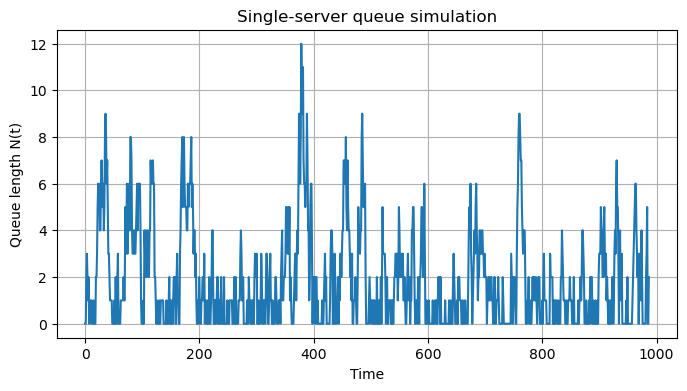

In [102]:
N = 1000
lam = 1.0
mu = 1.5

inter_arrival = np.random.exponential(1/lam, N)
service = np.random.exponential(1/mu, N)
arrival = np.cumsum(inter_arrival)

# time grid
t_grid = np.linspace(0, arrival[-1], 1000)

# compute queue length
N_t = queue_length(arrival, service, t_grid)

# plot
plt.figure(figsize=(8,4))
plt.plot(t_grid, N_t)
plt.xlabel("Time")
plt.ylabel("Queue length N(t)")
plt.title("Single-server queue simulation")
plt.grid()
plt.show()


In the example above $\lambda < \mu$, which means that the expected service time is $\frac{1}{\mu}$ is shorter than the expected 
time to the next arrival, which is $ \frac{1}{\lambda}$, implying shorter queues.


When $\lambda > \mu$, the service time in average is shorter that the arrival time, resulting in larger queues, and when $\lambda = \mu$, we have a border situation. Let us next simulate
the queue length for different values of $\lambda$ and  $\mu$;


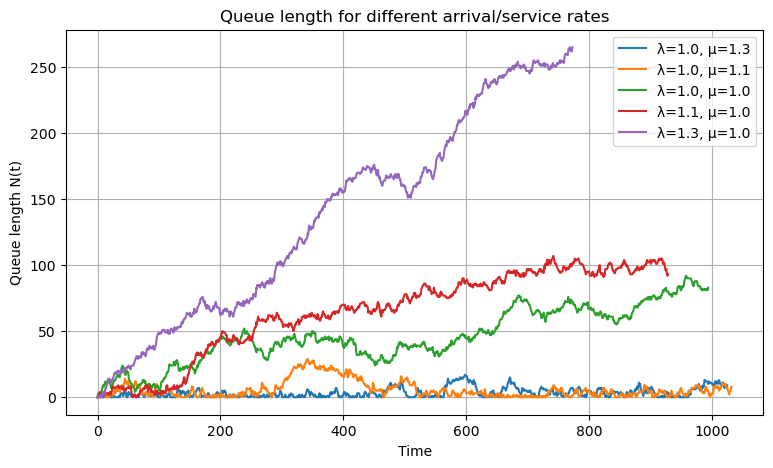

In [104]:
configs = [
    (1.0, 1.3),
    (1.0, 1.1),
    (1.0, 1.0),
    (1.1, 1.0),
    (1.3, 1.0)
]

N = 1000
plt.figure(figsize=(9,5))
for lam, mu in configs:
    inter_arrival = np.random.exponential(1/lam, N)
    service = np.random.exponential(1/mu, N)
    arrival = np.cumsum(inter_arrival)
    t_grid = np.linspace(0, arrival[-1], 1000)
    N_t = queue_length(arrival, service, t_grid)
    label = f"λ={lam}, μ={mu}"
    plt.plot(t_grid, N_t, label=label)
    
plt.xlabel("Time")
plt.ylabel("Queue length N(t)")
plt.title("Queue length for different arrival/service rates")
plt.legend()
plt.grid()
plt.show()

In the simulation above we observe the largest queues for $ \lambda =1.3 $ and $ \mu =1.0$, while when the ratio $\frac{\lambda }{\mu}$ decreases, the 
the queue length also decreases. 



## 5. Introduction to Brownian Motion  
In this exercise we simulate Brownian motion $W_t$ as a rescaled limit of random walks, $W_n(t)$.


First we simulate the random walk $S_k= \sum_{i=1}^k X_i$, where $X_i$ is a random variable, taking values $+ 1$ and $ -1$ with equal probabilities.


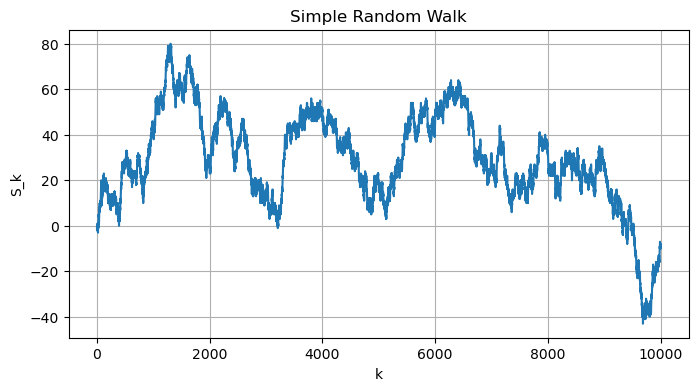

In [148]:
n = 10000
X = np.random.choice([-1, 1], size = n)
S = np.cumsum(X)

plt.figure(figsize=(8,4))
plt.plot(range(1, n+1), S)
plt.xlabel("k")
plt.ylabel("S_k")
plt.title("Simple Random Walk")
plt.grid()
plt.show()

   
Next we plot the stochastic process; $ W_n(t)$ for different values of $n, \quad n \in \{ 10^2, 10^3, ... , 10^6\}$, where
$$
W_n(t):= \frac{1}{\sqrt{n}}S_{[nt]}=  \frac{1}{\sqrt{n}} \sum_{i=1}^{[nt]} X_i, \quad t \in [0,1].
$$

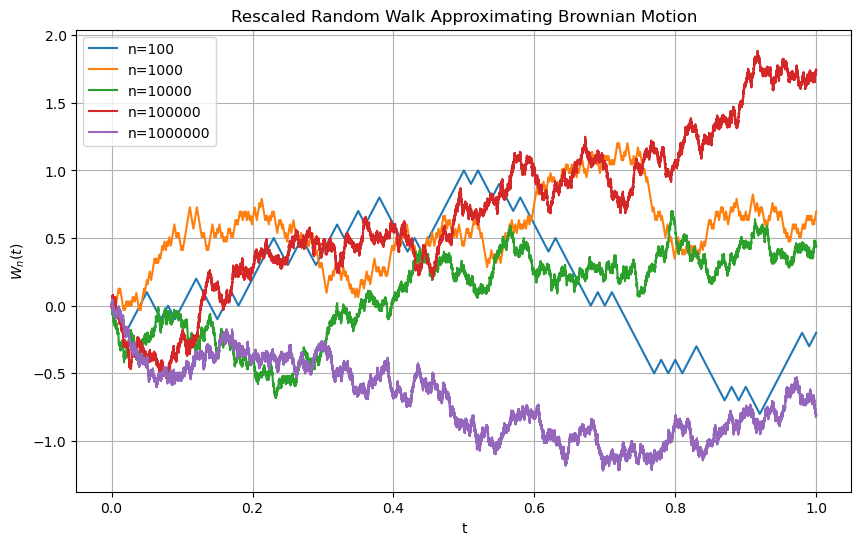

In [151]:
# simulation function for various n
def simulate_Wn(n):
    X = np.random.choice([-1, 1], size=n)
    S = np.cumsum(X)    
    W = S / np.sqrt(n)
    t = np.arange(1, n+1) / n    
    return t, W

n_values = [100, 1000, 10000, 100000, 1000000]
plt.figure(figsize=(10,6))
for n in n_values:
    t, W = simulate_Wn(n)
    plt.plot(t, W, label=f"n={n}")

plt.xlabel("t")
plt.ylabel(r"$W_n(t)$")
plt.title("Rescaled Random Walk Approximating Brownian Motion")
plt.legend()
plt.grid()
plt.show()


Let us fix $s< t < 1$, for example $ s=0.25, ~t=0.5$, and simulate many independent copies of $W_n(s)~$, $W_n(t)~$ and
$ W_n(t)-W_n(s)$. 

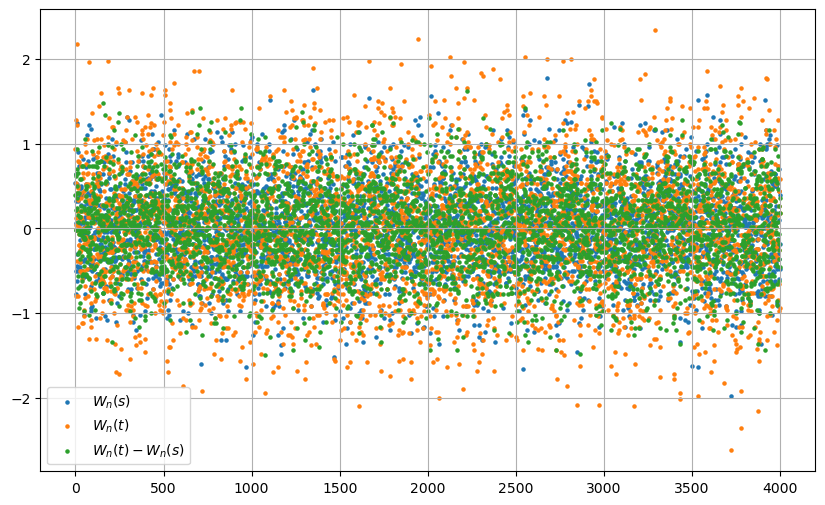

In [150]:
n = 10000
M = 4000   # number of independent simulations

s = 0.25
t = 0.5
k_s = int(n * s)
k_t = int(n * t)
Ws = []
Wt = []
increments = []
for _ in range(M):
    X = np.random.choice([-1, 1], size=n)
    S = np.cumsum(X)
    W = S / np.sqrt(n)
    ws = W[k_s - 1]
    wt = W[k_t - 1]
    Ws.append(ws)
    Wt.append(wt)
    increments.append(wt - ws)

Ws = np.array(Ws)
Wt = np.array(Wt)
increments = np.array(increments)

# A scatterplot describing distribution of values
plt.figure(figsize=(10,6))
plt.scatter(range(M), Ws, s=5, label=r"$W_n(s)$")
plt.scatter(range(M), Wt, s=5, label=r"$W_n(t)$")
plt.scatter(range(M), increments, s=5, label=r"$W_n(t)-W_n(s)$")
plt.legend()
plt.grid()
plt.show()

We expect $W_n(s) \thickapprox \mathrm{N}(0,s)~$, $W_n(t)\thickapprox \mathrm{N}(0,t)~$ and $W_n(t)-W_n(s)\thickapprox \mathrm{N}(0,t-s)$, for large $n$, hence we plot the histograms in order to compare the empirical distributions with the corresponding normal distribution.

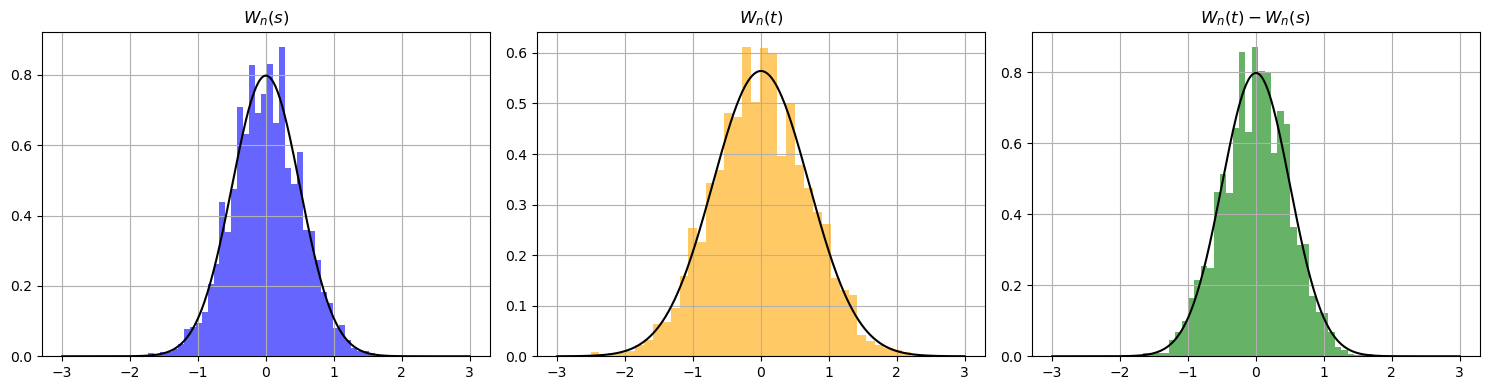

In [116]:
x = np.linspace(-3, 3, 400)

fig, axes = plt.subplots(1, 3, figsize=(15,4))
axes[0].hist(Ws, bins=40, density=True, alpha=0.6, color='blue')
pdf_s = (1/np.sqrt(2*np.pi*s))*np.exp(-x**2/(2*s))
axes[0].plot(x, pdf_s, 'k')

axes[0].set_title(r"$W_n(s)$")
axes[0].grid()

axes[1].hist(Wt, bins=40, density=True, alpha=0.6, color='orange')
pdf_t = (1/np.sqrt(2*np.pi*t))*np.exp(-x**2/(2*t))
axes[1].plot(x, pdf_t, 'k')
axes[1].set_title(r"$W_n(t)$")
axes[1].grid()

var = t - s
axes[2].hist(increments, bins=40, density=True, alpha=0.6, color='green')
pdf_inc = (1/np.sqrt(2*np.pi*var))*np.exp(-x**2/(2*var))
axes[2].plot(x, pdf_inc, 'k')
axes[2].set_title(r"$W_n(t)-W_n(s)$")
axes[2].grid()

plt.tight_layout()
plt.show()


By taking $ n=10^5$, we already observe the fitting of the normal distribution to the simulated values, and the plots visibly improve for larger values of $n$.